<a href="https://colab.research.google.com/github/yuhui-0611/ESAA/blob/main/ESAA_OB_WEEK06_2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 5.1 합성곱 신경망

- 순전파 과정에 따라 계산된 오차 정보가 신경망의 모든 노드로 전송되는데, 해당 과정이 복잡하고 시간이 오래 걸리기에 합성곱 신경망이 등장
- 합성곱 신경망
  - 이미지 전체를 한 번에 계산하는 것이 아닌 이미지의 국소적 부분을 계산함으로써 시간과 자원 절약 및 이미지의 세밀한 부분까지 분석 가능

## 합성곱 신경망 구조

- 합성곱 신경망
  - 다차원 배열 데이터를 처리하도록 구성
  1.  입력층
  2. 합성곱층
  3.  풀링층
  4.  완전 연결층
  5.  출력층

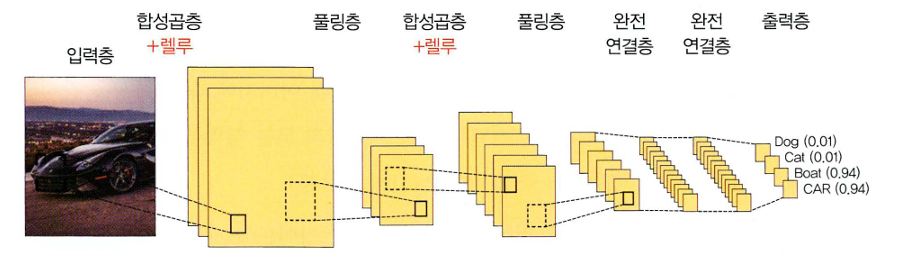

- 합성곱층과 풀링층을 거치며 입력 이미지의 주요 특성 벡터를 추출
- 추축된 주요 특성 벡터들은 완전연결층을 거쳐 1차원 벡터로 변환
- 마지막으로 출력층에서 활성하 함수인 softmax 함수를 사용하여 최종 결과 출력

### **1. 입력층**

- 입력 이미지 데이터가 최초로 거치게 되는 계층
- 이미지는 단순 1차원이 아닌 높이, 너비, 채널의 값을 갖는 3차원 데이터
  - 채널 = 이미지가 gray scale이면 1, color면 3의 값을 가짐
  - ex. 높이 4, 너비 4, 컬러 3 => (4,4,3)

### **2. 합성곱층**

- 입력 데이터에서 특성 추출
- 입력 이미지가 들어왔을 때 이미지에 대한 특성을 감지하기 위해 커널이나 필터 사용
  - 커널/필터 : 모든 영역을 훑으며 특성 추출
  - 이렇게 추출된 결과물 = 특성 맵 (feature map)

< 커널 >
- 3x3,5x5 크기로 적용되는 것이 일반적
- 스트라이드라는 지정된 간격에 따라 순차적으로 이동
- ex. stride = 1일 때 이동하는 과정
  - 1단계. 입력 이미지에 3x3 필터 적용
    - 입력 이미지와 3x3 필터를 포개 놓고 대응 숫자끼리 곱한 후 모두 더함

    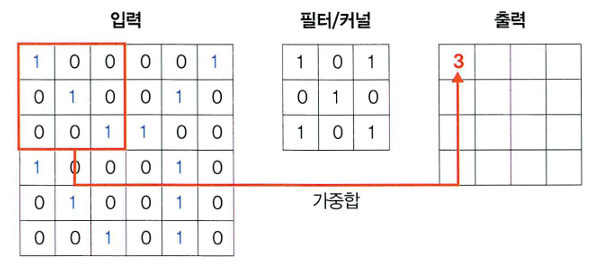

  - 2단계. 필터가 1만큼 이동

  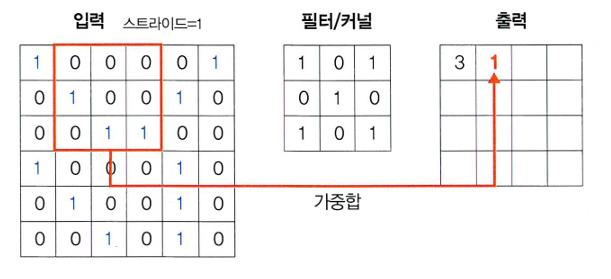

  - 3단계. 필터가 1만큼 두 번째 이동

  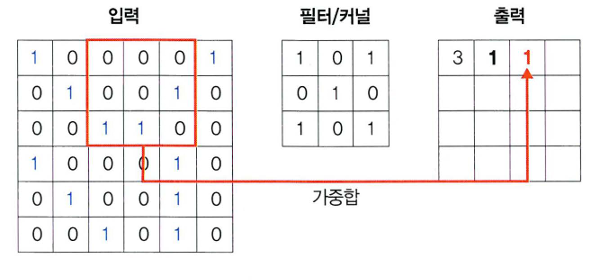

  - 4단계. 필터가 1만큼 세 번째 이동
  - 5단계. 필터가 1만큼 네 번째 이동
  - 6단계. 필터가 1만큼 마지막으로 이동

- 이렇게 커널은 스트아리드 간격만큼 순회하며 모든 입력 값과의 합성곱 연산으로 새로운 특성 맵을 만듦
- 앞 예제에서는 gray scale에서의 커널과 스트라이드의 상호작용으로 원본 (6,6,1)가 (4,4,1) 크기의 특성 맵으로 줄어듦

< 컬러 >

- 앞서 다룬 gray scale 이미지와 구분되는 특징
  - 필터 채널 = 3
  - RGB 각각에 서로 다른 가중치로 합성곱 적용 후 결과를 더함
  - 그 외 스트라이드 및 연산법은 동일
  - 필터 채널이 3인 것이지, 필터 개수가 3인 것은 X

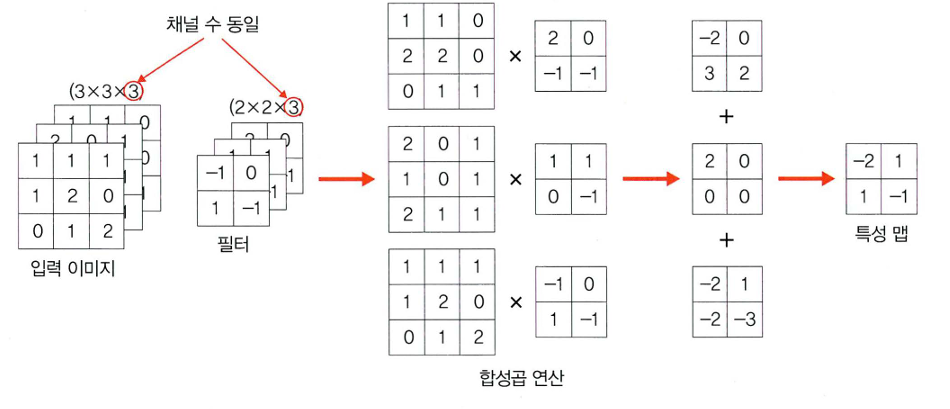

- 위의 그림이 필터 개수 1일 때의 그림이었다면, 아래 그림은 필터가 2개 이상일 때의 합성곱 연산임

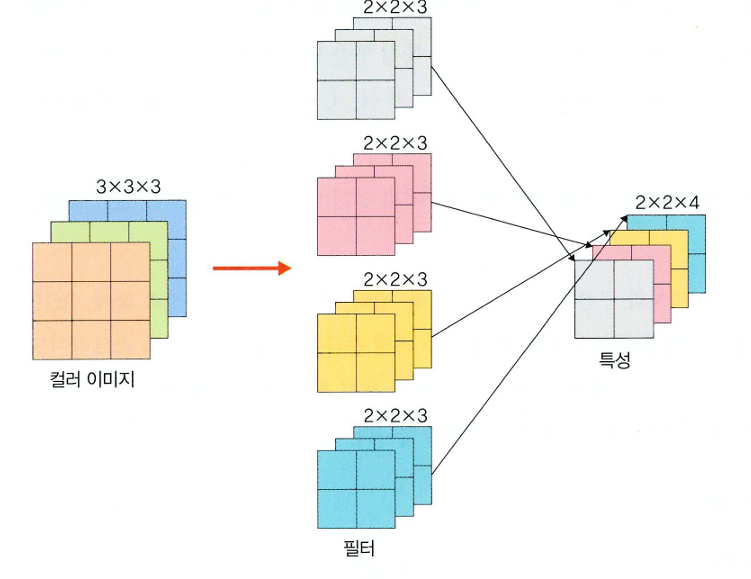

- 입력 데이터: 𝑊1×𝐻1×𝐷1(𝑊1: 가로, 𝐻1: 세로, 𝐷1: 채널 또는 깊이)
- 하이퍼파라미터
  - 필터 개수: 𝐾
  - 필터 크기: 𝐹
  - 스트라이드: 𝑆
  - 패딩: 𝑃
- 출력 데이터
  - 𝑊2 = (𝑊1-𝐹+2𝑃)/𝑆+1
  - 𝐻2 = (𝐻1−𝐹+2𝑃)/𝑆+1
  - 𝐷2 = 𝐾

### **3. 풀링층**

- 합성곱층과 유사하게 특성 맵의 차원을 down sampling하여 연산량 감소시키고 주요 특성 벡터를 추출하여 학습을 효과적으로 할 수 있게 함
  - = 이미지 축소
- **최대 풀링** : 대상 영역에서 최댓값을 추출
- **평균 풀링** : 대상 영역에서 평균을 반환

< 최대 풀링 과정 >


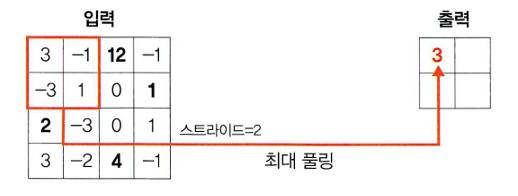

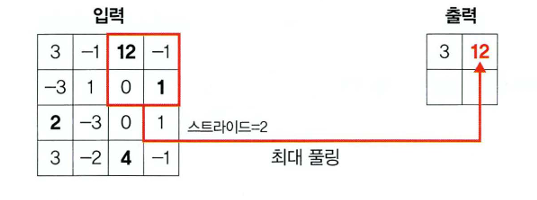

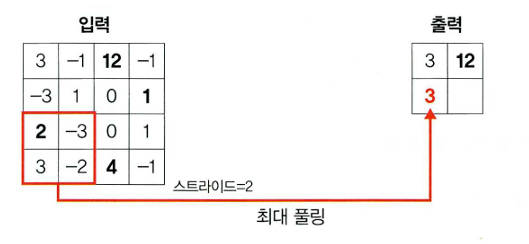

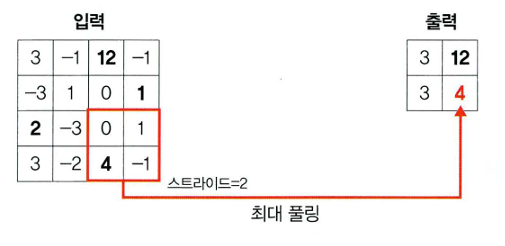

< 평균 풀링 >
- 각 필터의 평균으로 계산

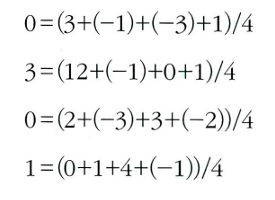

< 최대 풀링 vs 평균 풀링 >

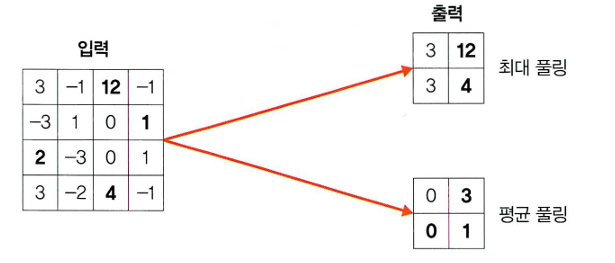

### **4. 완전 연결층**

- 합성곱층과 풀링층을 거쳐 차원이 축소된 특성 맵은 완전연결층으로 전달
- 이 과정에서 이미지는 3차원에서 1차원 벡터로 펼처짐

### **5. 출력층**

- 소프트맥스 활성화 함수 사용
- 입력받은 값을 0~1 사이의 값으로 출력
- 마지막 출력층의 소프트맥스 함수를 사용하여 이미지가 각 레이블에 속할 확률 값이 출력
- 가장 높은 확률 값을 갖는 레이블이 최종 값으로 선정됨

## 1D, 2D, 3D 합성곱

< 1D 합성곱 >

- 필터가 시간을 축으로 좌우로만 이동할 수 있는 합성곱

< 2D 합성곱 >

- 방향 두 개로 움직이는 형태

< 3D 합성곱 >

- 방향 세 개로 움직이는 형태

### 3D 입력을 갖는 2D 합성곱

- 입력이 3D임에도 출력 형태가 2D 행렬을 취하는 것
- 필터에 대한 길이가 입력 채널의 길이(L)와 같기 때문에 2D를 가지게 됨
- 즉, 입력 (W,H,L)에 필터 (k,k,L)를 적용하면 출력은 (W,H)가 됨